In [ ]:
# siamese_mnist_geom_gray.py
# A JAX/Flax training script:
# - MNIST pair generator with geometric transforms (rot k*90°+shift+noise+gray transformation)
#   plus gray-level affine I' = a I + b.
# - Siamese encoder; prediction head regresses 2x2 matrix M and scalars (a,b).
# - Loss: Frobenius norm on M + L2 on (a,b).

import math
import os
import numpy as np
import time
from typing import Tuple, Dict, Any

from functools import partial
import jax
from jax import lax
import jax.numpy as jnp
import optax
from flax import linen as nn
from flax import serialization
from flax.training import train_state, checkpoints
import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
def norm_per_image(x: jnp.ndarray, eps: float = 1e-6) -> jnp.ndarray:
    """
    Per-image standardization (zero mean, unit std) for gray-level invariance.
    x: [B,H,W] in [0,1] -> standardized [B,H,W]
    """
    m = x.mean(axis=(1, 2), keepdims=True)
    v = jnp.var(x, axis=(1, 2), keepdims=True)
    return (x - m) / jnp.sqrt(v + eps)

def prepare_example(example):
    # From TFDS dict -> (image, label)
    img = example["image"]
    img = jnp.array(img, dtype=jnp.float32) / 255.0  # 28x28x1
    img = img[...,0]  # 28x28
    return img

# ----------------------------
# Centered affine warp (general 2x2 M), bilinear sampling
# ----------------------------
def _make_centered_warper(H: int, W: int):
    """Build a function warp(x, M, t) applying an inverse affine warp
       around the image center. x:[B,H,W], M:[B,2,2], t:[B,2] -> [B,H,W]."""
    # Fixed target pixel grid (row-major)
    ys = jnp.arange(H, dtype=jnp.float32)
    xs = jnp.arange(W, dtype=jnp.float32)
    grid_y, grid_x = jnp.meshgrid(ys, xs, indexing="ij")  # [H,W]
    cy = (H - 1) * 0.5
    cx = (W - 1) * 0.5

    # Centered coordinates (x first, then y)
    coords = jnp.stack([grid_x - cx, grid_y - cy], axis=-1)  # [H,W,2]

    def _bilinear_sample(img, y, x):
        """img:[H,W], y/x:[H,W] float -> bilinear sample [H,W]."""
        H_, W_ = img.shape
        x = jnp.clip(x, 0.0, W_ - 1.0001)
        y = jnp.clip(y, 0.0, H_ - 1.0001)

        x0 = jnp.floor(x).astype(jnp.int32); x1 = jnp.clip(x0 + 1, 0, W_ - 1)
        y0 = jnp.floor(y).astype(jnp.int32); y1 = jnp.clip(y0 + 1, 0, H_ - 1)

        wx = x - x0.astype(jnp.float32)
        wy = y - y0.astype(jnp.float32)

        def gather(ix, iy):
            idx = iy * W_ + ix
            return jnp.take(img.reshape(-1), idx.reshape(-1)).reshape(img.shape)

        I00 = gather(x0, y0); I10 = gather(x1, y0)
        I01 = gather(x0, y1); I11 = gather(x1, y1)

        return ((1 - wx) * (1 - wy) * I00 +
                wx       * (1 - wy) * I10 +
                (1 - wx) * wy       * I01 +
                wx       * wy       * I11)

    def _warp_single(img, M, t):
        # Ensure types
        t = t.astype(coords.dtype)
        reg = 1e-3
        Minv = jnp.linalg.inv(M + reg * jnp.eye(2, dtype=M.dtype))
        # inverse map in centered coords: x_in_c = Minv @ (x_out_c - t)
        src_c = (coords - t[None, None, :]) @ Minv.T
        sx = src_c[..., 0] + cx
        sy = src_c[..., 1] + cy
        return _bilinear_sample(img, sy, sx)

    def warp(x, M, t):
        # x:[B,H,W], M:[B,2,2], t:[B,2]
        return jax.vmap(_warp_single, in_axes=(0, 0, 0))(x, M, t)

    # IMPORTANT: return the inner function from the factory
    return warp

# Build the 28x28 warper
warp_28 = _make_centered_warper(28, 28)

In [ ]:
class Encoder(nn.Module):
    d: int = 128
    @nn.compact
    def __call__(self, x):
        x = x[..., None]
        x = nn.Conv(32, (5,5), (2,2))(x); x = nn.relu(x)
        x = nn.Conv(64, (3,3), (2,2))(x); x = nn.relu(x)
        x = nn.Conv(64, (3,3), (1,1))(x); x = nn.relu(x)
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(256)(x); x = nn.relu(x)
        return nn.Dense(self.d)(x)

class MLP(nn.Module):
    h: int; out: int
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.h)(x); x = nn.relu(x)
        return nn.Dense(self.out)(x)

class TripletNet(nn.Module):
    d: int = 128
    h: int = 256
    use_projector: bool = True
    @nn.compact
    def __call__(self, x):  # x: [B,28,28]
        z = Encoder(self.d)(norm_per_image(x))
        if self.use_projector:
            z = MLP(self.h, self.d)(z)
        # L2-normalize for cosine distance
        z = z / (jnp.linalg.norm(z, axis=1, keepdims=True) + 1e-9)
        return z  # [B,d], unit-norm

def triplet_loss(params, apply_fn, batch, margin=0.2):
    xa, xp, xn = batch  # [B,28,28] each
    ea = apply_fn({'params': params}, xa)  # [B,d], unit norm
    ep = apply_fn({'params': params}, xp)
    en = apply_fn({'params': params}, xn)

    # cosine distances: d = 1 - dot(u,v)
    dap = 1.0 - jnp.sum(ea * ep, axis=1)   # [B]
    dan = 1.0 - jnp.sum(ea * en, axis=1)   # [B]

    # classic margin triplet: max(0, d_ap - d_an + m)
    losses = jnp.maximum(0.0, dap - dan + margin)
    loss = jnp.mean(losses)

    # helpful metrics
    frac_viol = jnp.mean((dap + margin > dan).astype(jnp.float32))
    metrics = {
        "loss": loss,
        "d_ap": jnp.mean(dap),
        "d_an": jnp.mean(dan),
        "viol": frac_viol,  # fraction violating the margin
    }
    return loss, metrics

def create_train_state(rng, model, lr=3e-4):
    dummy = jnp.zeros((2,28,28), dtype=jnp.float32)
    variables = model.init(rng, dummy)
    params = variables["params"]
    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(lr),
    )
    return train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

@jax.jit
def train_step(state, batch, margin=0.2):
    def _loss_only(p):
        return triplet_loss(p, state.apply_fn, batch, margin=margin)
    (loss, metrics), grads = jax.value_and_grad(_loss_only, has_aux=True)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, metrics

In [ ]:
# ----------------------------
# TFDS input
# ----------------------------
def get_mnist_ds(split="train", shuffle=True, repeat=True):
    ds = tfds.load("mnist", split=split, as_supervised=False)
    if shuffle:
        ds = ds.shuffle(10_000, seed=0, reshuffle_each_iteration=True)
    ds = ds.map(lambda ex: {"image": ex["image"]}, num_parallel_calls=tf.data.AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(1, drop_remainder=True).prefetch(128)  # we'll take single examples in generator
    return tfds.as_numpy(ds.unbatch())  # expose dicts like {"image": np.array}

In [ ]:
def make_triplet_gen(
    rng,
    ds,
    batch_size,
    a_range=(0.7, 1.4),
    b_range=(-0.2, 0.2),
    sigma_shift=1.0,
    noise_std=None,          # None, float, or (lo, hi)
):
    """
    Yields (xa, xp, xn) where xa & xp are two aug views of the SAME base image,
    and xn is an aug view of a DIFFERENT base image. Shapes: [B,28,28], values in [0,1].

    Shift model: t ~ N(0, sigma_shift^2 I_2) pixels (applied in centered coords).
    Noise model: x <- x + N(0, sigma^2) with sigma from noise_std.
    """
    ds_iter = iter(ds)
    key = rng

    def sample_T(k, B):
        """
        Returns:
          k : updated PRNGKey
          M : [B,2,2] rotation matrices (no mirror)
          t : [B,2] pixel shifts ~ N(0, sigma_shift^2) per axis
          a : [B] gray gain
          b : [B] gray bias
        """
        k, k_th, k_sh, k_a, k_b = jax.random.split(k, 5)
        theta = jax.random.uniform(k_th, (B,), dtype=jnp.float32,
                                   minval=-jnp.pi, maxval=jnp.pi)
        cos, sin = jnp.cos(theta), jnp.sin(theta)
        M = jnp.stack([jnp.stack([cos, -sin], axis=-1),
                       jnp.stack([sin,  cos], axis=-1)], axis=-2)  # [B,2,2]
        t = jax.random.normal(k_sh, (B, 2), dtype=jnp.float32) * float(sigma_shift)
        a = jax.random.uniform(k_a, (B,), dtype=jnp.float32, minval=a_range[0], maxval=a_range[1])
        b = jax.random.uniform(k_b, (B,), dtype=jnp.float32, minval=b_range[0], maxval=b_range[1])
        return k, M, t, a, b

    def _sample_sigma(k, B, spec):
        """Return per-sample σ: shape [B]. spec=None | float | (lo,hi)."""
        if spec is None:
            return jnp.zeros((B,), dtype=jnp.float32)
        if isinstance(spec, (float, int)):
            return jnp.full((B,), float(spec), dtype=jnp.float32)
        lo, hi = float(spec[0]), float(spec[1])
        return jax.random.uniform(k, (B,), dtype=jnp.float32, minval=lo, maxval=hi)

    while True:
        # 2B bases: first B for (anchor,positive), second B for negatives
        imgs = [prepare_example(next(ds_iter)) for _ in range(2 * batch_size)]
        base = jnp.stack(imgs, 0).astype(jnp.float32)  # [2B,28,28]
        base_ap = base[:batch_size]
        base_n  = base[batch_size:]

        # keys
        key, kA, kP, kN, kNA, kNP, kNN, kSA, kSP, kSN = jax.random.split(key, 10)

        # sample transforms
        kA, MA, tA, aA, bA = sample_T(kA, batch_size)
        kP, MP, tP, aP, bP = sample_T(kP, batch_size)
        kN, MN, tN, aN, bN = sample_T(kN, batch_size)

        # apply transforms + gray
        xa = aA[:, None, None] * warp_28(base_ap, MA, tA) + bA[:, None, None]
        xp = aP[:, None, None] * warp_28(base_ap, MP, tP) + bP[:, None, None]
        xn = aN[:, None, None] * warp_28(base_n,  MN, tN) + bN[:, None, None]

        # per-sample noise σ
        sig_a = _sample_sigma(kSA, batch_size, noise_std)
        sig_p = _sample_sigma(kSP, batch_size, noise_std)
        sig_n = _sample_sigma(kSN, batch_size, noise_std)

        # add Gaussian noise unconditionally (σ may be zero)
        xa = xa + jax.random.normal(kNA, xa.shape) * sig_a[:, None, None]
        xp = xp + jax.random.normal(kNP, xp.shape) * sig_p[:, None, None]
        xn = xn + jax.random.normal(kNN, xn.shape) * sig_n[:, None, None]

        yield xa, xp, xn

In [ ]:
import matplotlib.pyplot as plt

def show_triplet_batch(train_gen, n_examples=5):
    """Display n_examples triplets (anchor, positive, negative) from generator."""
    xa, xp, xn = next(train_gen)           # each [B,28,28]
    xa, xp, xn = np.array(xa), np.array(xp), np.array(xn)

    plt.figure(figsize=(9, 3))
    for i in range(n_examples):
        for j, img in enumerate([xa[i], xp[i], xn[i]]):
            plt.subplot(n_examples, 3, i*3 + j + 1)
            plt.imshow(img, cmap="gray")
            if i == 0:
                plt.title(["Anchor", "Positive", "Negative"][j])
            plt.axis("off")
    plt.tight_layout()
    plt.show()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.JBQJ09_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.JBQJ09_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


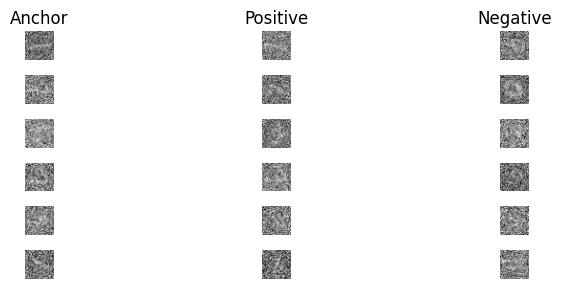

In [ ]:
# ------------------------
# Main training loop (SimSiam, pose-invariant)
# ------------------------
rng = jax.random.PRNGKey(42)
batch_size = 128

train_ds = get_mnist_ds("train")
test_ds  = get_mnist_ds("test", shuffle=False, repeat=True)

train_gen = make_triplet_gen(rng,                     train_ds, batch_size, noise_std=1)
test_gen  = make_triplet_gen(jax.random.PRNGKey(999), test_ds,  batch_size, noise_std=1)
show_triplet_batch(train_gen, n_examples=6)

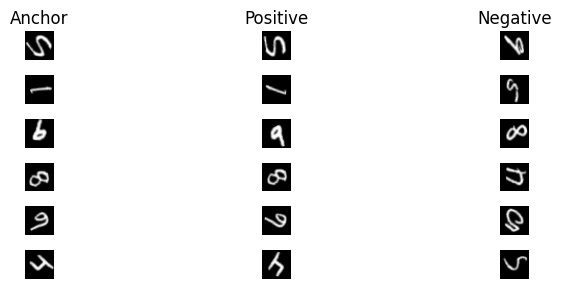

In [ ]:
clean_gen = make_triplet_gen(rng, train_ds, batch_size, noise_std=0)
show_triplet_batch(clean_gen, n_examples=6)

In [ ]:
model = TripletNet(d=128, h=256, use_projector=True)
state = create_train_state(jax.random.PRNGKey(0), model, lr=3e-4)

ckpt_file = "./mnist_triplet.msgpack"
loaded = False
if os.path.exists(ckpt_file):
    with open(ckpt_file, "rb") as f:
        state = serialization.from_bytes(state, f.read())
    loaded = True
    print(f"✅ Loaded trained model from {ckpt_file}. Skipping training.")

steps      = 20_000
log_every  = 100
eval_every = 1000
margin     = 0.2

if not loaded:
    print("🚀 No saved model found. Training from scratch…")
    t0 = time.time()
    for step in range(1, steps + 1):
        xa, xp, xn = next(train_gen)
        state, metrics = train_step(state, (xa, xp, xn), margin=margin)

        if step % log_every == 0:
            dt = time.time() - t0
            print(f"[{step:5d}] loss={metrics['loss']:.8f}  "
                  f"d_ap={metrics['d_ap']:.8f}  d_an={metrics['d_an']:.8f}  "
                  f"viol%={100*metrics['viol']:.1f}  ({dt:.1f}s)")
            t0 = time.time()

        # ---- EVAL ----
        if step % eval_every == 0:
            txa, txp, txn = next(test_gen)
            test_loss, test_metrics = triplet_loss(state.params, state.apply_fn, (txa, txp, txn), margin=margin)
            print(f"  Eval: loss={float(test_loss):.8f}  "
                  f"d_ap={float(test_metrics['d_ap']):.8f}  "
                  f"d_an={float(test_metrics['d_an']):.8f}  "
                  f"viol%={100*float(test_metrics['viol']):.1f}")

    with open(ckpt_file, "wb") as f:
        f.write(serialization.to_bytes(state))
    print(f"💾 Saved trained model to {ckpt_file}")

🚀 No saved model found. Training from scratch…
[  100] loss=0.16746804  d_ap=0.15746009  d_an=0.20089319  viol%=86.7  (75.3s)
[  200] loss=0.13887307  d_ap=0.16882572  d_an=0.27354074  viol%=75.0  (67.0s)
[  300] loss=0.13965587  d_ap=0.18467718  d_an=0.30983332  viol%=65.6  (71.0s)
[  400] loss=0.10318314  d_ap=0.17049627  d_an=0.37098327  viol%=54.7  (65.6s)
[  500] loss=0.13942492  d_ap=0.16468146  d_an=0.28609183  viol%=69.5  (66.4s)
[  600] loss=0.10373936  d_ap=0.16438448  d_an=0.35305613  viol%=57.8  (65.3s)
[  700] loss=0.12205582  d_ap=0.15635082  d_an=0.33649838  viol%=64.1  (65.6s)
[  800] loss=0.11774352  d_ap=0.16578722  d_an=0.31650090  viol%=68.0  (65.7s)
[  900] loss=0.11844854  d_ap=0.18206425  d_an=0.35624054  viol%=58.6  (67.1s)
[ 1000] loss=0.09461284  d_ap=0.18597767  d_an=0.41699660  viol%=43.0  (66.4s)
  Eval: loss=0.10857716  d_ap=0.19696675  d_an=0.42605188  viol%=50.0
[ 1100] loss=0.12630974  d_ap=0.19374239  d_an=0.38515937  viol%=56.2  (68.4s)
[ 1200] loss=0

In [ ]:
!pip install -q umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.05, n_components=3, n_jobs=1, n_neighbors=30, random_state=0, verbose=True)
Sat Nov  8 10:27:51 2025 Construct fuzzy simplicial set
Sat Nov  8 10:27:51 2025 Finding Nearest Neighbors
Sat Nov  8 10:27:51 2025 Building RP forest with 10 trees
Sat Nov  8 10:27:56 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Sat Nov  8 10:28:16 2025 Finished Nearest Neighbor Search
Sat Nov  8 10:28:19 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sat Nov  8 10:28:49 2025 Finished embedding


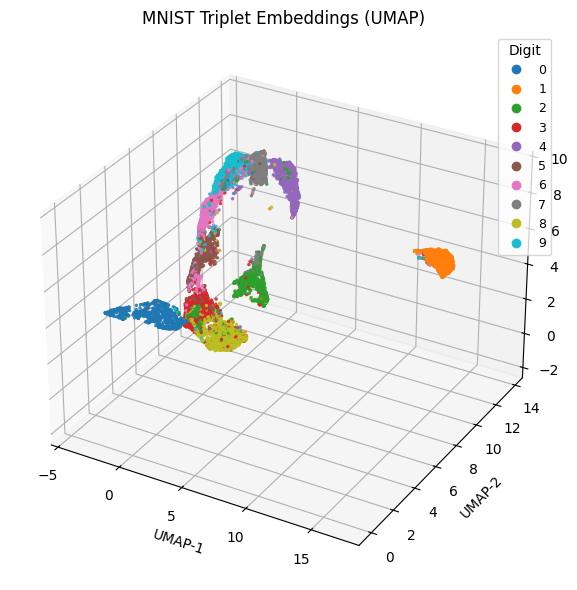

Embeddings: (10000, 128) Reduced: (10000, 3)


In [ ]:
import umap

# ---------- Labeled MNIST loader ----------
def get_mnist_labeled(split="test"):
    ds = tfds.load("mnist", split=split, shuffle_files=False, as_supervised=True)
    def _prep(img, label):
        img = tf.cast(img, tf.float32) / 255.0      # [28,28,1]
        img = tf.squeeze(img, axis=-1)              # [28,28]
        return img, label
    return ds.map(_prep, num_parallel_calls=tf.data.AUTOTUNE)

def dataset_to_batches(ds, batch_size=512):
    ds = ds.batch(batch_size)
    for imgs, labels in tfds.as_numpy(ds):
        yield imgs.astype(np.float32), labels.astype(np.int32)

# ---------- Encode with your trained TripletNet ----------
def encode_batch(state, model, x_np):
    x = jnp.asarray(x_np)                # [B,28,28]
    e = model.apply({'params': state.params}, x)  # [B,d] unit-norm
    return np.array(e)

def embed_split(state, model, split="test", batch_size=512):
    ds = get_mnist_labeled(split)
    embs, labs = [], []
    for imgs, labels in dataset_to_batches(ds, batch_size=batch_size):
        embs.append(encode_batch(state, model, imgs))
        labs.append(labels)
    E = np.concatenate(embs, axis=0)  # [N,d]
    y = np.concatenate(labs, axis=0)  # [N]
    return E, y

# ---------- UMAP reduction + plot ----------
def umap_reduce(embs, n_neighbors=30, min_dist=0.1, random_state=0):
    import umap
    reducer = umap.UMAP(
        n_components=3,
        metric="cosine",
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state,
        verbose=True,
    )
    Z = reducer.fit_transform(embs)
    return Z, reducer

def plot_3d_matplotlib(Z, y, title="MNIST Triplet Embeddings (UMAP)"):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(Z[:,0], Z[:,1], Z[:,2],
                    c=y, cmap="tab10", s=6, alpha=0.9, edgecolors='none')
    handles = [plt.Line2D([], [], marker='o', linestyle='',
                          color=plt.cm.tab10(i/10.), label=str(i)) for i in range(10)]
    ax.legend(handles=handles, title="Digit", loc="best", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2"); ax.set_zlabel("UMAP-3")
    plt.tight_layout()
    plt.show()

# ---------- Run (choose split: "train", "test", or "train+test") ----------
E, y = embed_split(state, model, split="test", batch_size=1024)
Z, reducer = umap_reduce(E, n_neighbors=30, min_dist=0.05, random_state=0)
plot_3d_matplotlib(Z, y)
print("Embeddings:", E.shape, "Reduced:", Z.shape)


In [ ]:
def plot_3d_plotly(Z, y, title="MNIST Triplet Embeddings (UMAP)"):
    import numpy as np
    import pandas as pd
    import plotly.express as px

    df = pd.DataFrame({
        "UMAP-1": Z[:,0],
        "UMAP-2": Z[:,1],
        "UMAP-3": Z[:,2],
        "label":  y.astype(int),
    })
    fig = px.scatter_3d(
        df, x="UMAP-1", y="UMAP-2", z="UMAP-3",
        color="label",
        color_discrete_sequence=px.colors.qualitative.T10,
        opacity=0.85,
        title=title,
    )
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(legend_title_text="Digit", margin=dict(l=0, r=0, t=40, b=0))
    fig.show()
plot_3d_plotly(Z, y)